# Linear Variational Method - Quantum Harmonic Oscillator (QHO)

In this notebook, We will solve using numeric (and symbolic) calculations the Quantum Harmonic Oscillator. We will approximate the energy eigenstates and wavefunctions by using a trial wave function (the variational trial function) that is a linear combination of a basis (specifically, we will use the eigenfunctions of the infinite square well of length L (symmetric about the origin)). This basis will not be complete since we will cut it and not use the infinite set that will make it complete (because the computer has finite resources).

---

## 1. The Hamiltonian

The Quantum Harmonic Oscillator is defined by its kinetic and potential energy operators:

$$\hat{H} = \hat{T} + \hat{V} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + \frac{1}{2}m\omega^2 x^2$$

Where $m$ is the mass, $\omega$ is the angular frequency, and $\hbar$ is the reduced Planck's constant. For computational simplicity, we will operate in natural units where $\hbar = m = \omega = 1$.

---

## 2. The Basis Set (Infinite Square Well)

To represent the continuous Hamiltonian operator $\hat{H}$ as a matrix, we must choose a complete set of orthonormal basis functions. We will use the analytical solutions of the 1D Infinite Square Well.

Because our QHO potential is centered at $x=0$, we define our infinite well over a symmetric domain from $-L/2$ to $L/2$. The corresponding normalized basis functions for $n = 1, 2, 3, \dots$ are (see derivation here (TODO add a link to a derivation I will add here)):

$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

We will artificially truncate this infinite basis to a finite size $N_{basis}$ to perform our numerical calculations.

---

## 3. Proof of the Variational Theorem

The Variational Principle states that the expectation value of the Hamiltonian for any valid trial wavefunction will always be greater than or equal to the true ground state energy $E_0$. 

**Proof:**
We begin by writing the expression for the expected energy of our trial state:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with exact eigenvalues $E_n$, such that $E_0 \le E_1 \le E_2 \le \dots$

Because these true eigenstates form a complete basis, we can utilize the resolution of the identity (completeness relation):

$$\hat{I} = \sum_{n=0}^{\infty} |\phi_n\rangle\langle\phi_n|$$

We leave the denominator as is, and insert this identity operator between the Hamiltonian and the trial wavefunction in the numerator:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} \langle \psi_{trial} | \hat{H} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

By applying the Hamiltonian operator to its true eigenstate ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$), the expression becomes:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} E_n \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Since $E_n \ge E_0$ for all states $n$, we can substitute $E_n$ with the ground state energy $E_0$ to establish an inequality:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge \sum_{n=0}^{\infty} E_0 \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Because $E_0$ is a constant, it factors out of the summation:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \sum_{n=0}^{\infty} \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

We can now recognize the resolution of the identity sitting inside the sum, and use it in reverse to collapse the sum back into the inner product of the trial state:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \langle \psi_{trial} | \psi_{trial} \rangle$$

Finally, we substitute this inequality back into our original energy equation:

$$E \ge \frac{E_0 \langle \psi_{trial} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

The inner products in the numerator and denominator perfectly cancel, leaving the final proven inequality:

$$E \ge E_0$$

---

### Alternative Proof: Linear Expansion

We can also prove the Variational Theorem by explicitly expanding the trial wavefunction as a linear combination of the exact eigenstates. 

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with corresponding exact eigenvalues $E_n$, where $E_0 \le E_1 \le E_2 \le \dots$

We express our arbitrary trial wavefunction $|\psi_{trial}\rangle$ as a linear sum of these true states:

$$|\psi_{trial}\rangle = \sum_{n=0}^{\infty} c_n |\phi_n\rangle$$

Where $c_n$ represents the complex expansion coefficients. 

First, we evaluate the numerator of the energy expectation value, $\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle$:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \left( \sum_{m=0}^{\infty} c_m^* \langle \phi_m | \right) \hat{H} \left( \sum_{n=0}^{\infty} c_n | \phi_n \rangle \right)$$

Applying the Hamiltonian to the right-hand states ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$) yields:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{m=0}^{\infty} \sum_{n=0}^{\infty} c_m^* c_n E_n \langle \phi_m | \phi_n \rangle$$

Because the exact eigenstates are mutually orthonormal ($\langle \phi_m | \phi_n \rangle = \delta_{mn}$), all terms where $m \neq n$ are zero, and the double sum collapses into a single sum:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2 E_n$$

Next, we evaluate the denominator, $\langle \psi_{trial} | \psi_{trial} \rangle$, using the same expansion and orthonormality principle:

$$\langle \psi_{trial} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2$$

Substituting both of these back into our total energy equation gives:

$$E = \frac{\sum_{n=0}^{\infty} |c_n|^2 E_n}{\sum_{n=0}^{\infty} |c_n|^2}$$

Since the true energies are strictly ordered such that $E_n \ge E_0$ for all $n$, replacing $E_n$ with the ground state energy $E_0$ in the numerator establishes a strict inequality:

$$E \ge \frac{\sum_{n=0}^{\infty} |c_n|^2 E_0}{\sum_{n=0}^{\infty} |c_n|^2}$$

Because $E_0$ is a constant, we can pull it entirely outside the summation:

$$E \ge E_0 \frac{\sum_{n=0}^{\infty} |c_n|^2}{\sum_{n=0}^{\infty} |c_n|^2}$$

The summations of the squared coefficients in the numerator and denominator are identical and cancel out perfectly, proving the theorem:

$$E \ge E_0$$

---

## 4. Derivation of the Linear Variational Method (The Secular Equation)

We now apply the Variational Theorem to a specific type of trial function: a linear combination of a finite, chosen basis set. Let $\{|\chi_j\rangle\}$ be a set of $N_{basis}$ basis functions (in our case, the infinite square well states). 

We express our trial wavefunction as:

$$|\psi_{trial}\rangle = \sum_{j=1}^{N_{basis}} c_j |\chi_j\rangle$$

Where $c_j$ are the unknown expansion coefficients. We substitute this expansion into the variational energy expectation value:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle} = \frac{\sum_{i=1}^{N} \sum_{j=1}^{N} c_i^* c_j \langle \chi_i | \hat{H} | \chi_j \rangle}{\sum_{i=1}^{N} \sum_{j=1}^{N} c_i^* c_j \langle \chi_i | \chi_j \rangle}$$

To simplify the notation, we define two matrix elements:
* **The Hamiltonian Matrix:** $H_{ij} = \langle \chi_i | \hat{H} | \chi_j \rangle$
* **The Overlap Matrix:** $S_{ij} = \langle \chi_i | \chi_j \rangle$

Substituting these into the energy equation yields:

$$E = \frac{\sum_{i,j} c_i^* c_j H_{ij}}{\sum_{i,j} c_i^* c_j S_{ij}}$$

To avoid taking the derivative of a complex fraction using the quotient rule, we rearrange the equation by multiplying the denominator to the left side:

$$E \sum_{i,j} c_i^* c_j S_{ij} = \sum_{i,j} c_i^* c_j H_{ij}$$

According to the Variational Principle, the optimal trial wavefunction is the one that minimizes the energy $E$. We find this minimum by requiring that the variation of the energy with respect to the coefficients is zero. In complex calculus, it is standard practice to treat $c_k$ and its complex conjugate $c_k^*$ as independent variables. Therefore, we take the partial derivative of both sides with respect to a specific coefficient $c_k^*$:

$$\frac{\partial E}{\partial c_k^*} \sum_{i,j} c_i^* c_j S_{ij} + E \sum_{j} c_j S_{kj} = \sum_{j} c_j H_{kj}$$

To find the minimum energy, we enforce the minimization condition: $\frac{\partial E}{\partial c_k^*} = 0$. The first term vanishes entirely, leaving:

$$E \sum_{j} c_j S_{kj} = \sum_{j} c_j H_{kj}$$

We can rearrange this by bringing all terms to one side and factoring out the $c_j$ coefficients:

$$\sum_{j} (H_{kj} - E S_{kj}) c_j = 0$$

This must hold true for all $k = 1, 2, \dots, N_{basis}$. This system of linear equations is known as the **Secular Equation**. Written in compact matrix notation, it becomes the generalized eigenvalue problem:

$$\mathbf{H}\mathbf{c} = E\mathbf{S}\mathbf{c}$$

**Application to our QHO Model:**
Because we have chosen the eigenstates of the infinite square well as our basis, our basis functions are mutually orthonormal. This means the overlap matrix simplifies completely to the identity matrix ($S_{ij} = \delta_{ij}$). Our generalized problem reduces to the standard eigenvalue problem, which we will solve using our Python numerical backend:

$$\mathbf{H}\mathbf{c} = E\mathbf{c}$$

------

> **Historical Note: Why is it called the "Secular" Equation?**
> The term "secular" comes from the Latin word *saeculum*, meaning an age, century, or a very long period of time. In the late 1700s, astronomers like Laplace and Lagrange were studying celestial mechanics, specifically trying to calculate the slow, long-term ("secular") perturbations of planetary orbits—changes that happen over thousands of years, as opposed to short-term periodic changes. 
>
> To find these long-term orbital frequencies, they had to solve a mathematical determinant equation that looked exactly like $|\mathbf{H} - E\mathbf{S}| = 0$. When quantum mechanics was developed a century later and physicists encountered the exact same matrix eigenvalue math, they simply kept the historical astronomy name!

---

## 5. Analytical Solution of the Infinite Square Well

To build our finite basis set, we require the exact analytical solutions to the 1D Infinite Square Well. Because our harmonic oscillator is centered at the origin, we define the boundaries of our infinite well symmetrically at $x = -L/2$ and $x = L/2$. 

The potential energy function is defined as:

$$V(x) = \begin{cases} 0 & -L/2 \le x \le L/2 \\ \infty & \text{otherwise} \end{cases}$$

Inside the well where $V(x) = 0$, the Time-Independent Schrödinger Equation simplifies to:

$$-\frac{\hbar^2}{2m}\frac{d^2\chi}{dx^2} = E\chi$$

We can rewrite this as a standard second-order differential equation:

$$\frac{d^2\chi}{dx^2} + k^2\chi = 0 \quad \text{where} \quad k = \frac{\sqrt{2mE}}{\hbar}$$

To make applying the boundary conditions mathematically simpler, we can introduce a coordinate transformation $u = x + L/2$. This shifts the left wall to $u = 0$ and the right wall to $u = L$. The general solution to the differential equation in this shifted coordinate system is:

$$\chi(u) = A \sin(ku) + B \cos(ku)$$

We now apply the impenetrable boundary conditions. The wavefunction must go to zero at the walls:

1.  **Left Wall (**$u = 0$**):**
    $$\chi(0) = A \sin(0) + B \cos(0) = B = 0$$
    This eliminates the cosine term entirely, leaving $\chi(u) = A \sin(ku)$.

2.  **Right Wall (**$u = L$**):**
    $$\chi(L) = A \sin(kL) = 0$$
    For a non-trivial solution ($A \neq 0$), the argument of the sine function must be an integer multiple of $\pi$:
    $$kL = n\pi \implies k_n = \frac{n\pi}{L} \quad \text{for} \quad n = 1, 2, 3, \dots$$

Substituting our momentum wave vector $k_n$ back into the energy definition $k^2 = 2mE/\hbar^2$ yields the exact energy eigenvalues for the infinite well:

$$E_n = \frac{n^2 \pi^2 \hbar^2}{2mL^2}$$

To find the normalization constant $A$, we require the total probability of finding the particle inside the well to be exactly 1:

$$1 = \int_{-L/2}^{L/2} |\chi_n(x)|^2 dx = A^2 \int_{0}^{L} \sin^2\left(\frac{n\pi u}{L}\right) du$$

Evaluating the integral gives $L/2$, which means:

$$A^2 \left(\frac{L}{2}\right) = 1 \implies A = \sqrt{\frac{2}{L}}$$

Finally, we substitute $A$, $k_n$, and our original coordinate $x = u - L/2$ back into the wavefunction to get the complete, normalized basis functions used in our variational matrix:

$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

In [11]:
# --- Imports ---

# 1. Jupyter Magic Commands (Forces notebook to reload external .py files)
%load_ext autoreload
%autoreload 2

# 1. Symbolic Mathematics (Analytical Derivations & Units)
import sympy as sp
from IPython.display import display, Math # For rendering LaTeX beautifully in Jupyter

# 2. Numerical Arrays and Matrices
import numpy as np

# 3. Scientific Computing (Integration and Eigenvalue Solvers)
from scipy.integrate import quad
from scipy.linalg import eigh

# 4. Visualization (Convergence and Error Graphs)
import matplotlib.pyplot as plt

# 5. Numerical integration methods (custom implementations)
from numerical_integration_methods import INTEGRATION_DISPATCH

import config as cfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# --- Variational Parameters ---
L = 10.0      # The domain size of the infinite well [-L/2, L/2]
N_BASIS = 50  # The size of the basis (k = 1, 2, ..., N_BASIS)
N_STATES = 5  # How many low-lying energy levels to track (should be << N_BASIS)

In [13]:
def basis_function(x, n, L) -> float:
    """
    Evaluates the n-th infinite square well basis function at position x.

    Parameters
    ----------
    x : float
        Position where the function is evaluated.
    n : int
        Basis index.
    L : float
        Width of the well.

    Returns
    -------
    float
        Value of the basis function at x.
    """
    normalization = np.sqrt(2.0 / L)
    argument = (n * np.pi * (x + L / 2.0)) / L
    
    return normalization * np.sin(argument)

def integrand_V(x, n, m, L, mass, omega) -> float:
    """
    The potential energy integrand: chi_n(x) * V(x) * chi_m(x).
    """
    chi_n = basis_function(x, n, L)
    chi_m = basis_function(x, m, L)
    
    V_x = 0.5 * mass * ((omega * x)**2)  # QHO Potential: 1/2 * mass * omega^2 * x^2
    
    return chi_n * V_x * chi_m

In [14]:
def build_hamiltonian_matrix(N_BASIS, L, mass, omega, integration_method='trapezoidal', N_GRID=1000):
    """Builds the N_BASIS x N_BASIS Hamiltonian matrix
    
    Parameters
    ----------
    N_BASIS : int
        The size of the basis (k = 1, 2, ..., N_BASIS)
    L : float
        The domain size of the infinite well [-L/2, L/2]
    mass : float
        The mass of the particle
    omega : float
        The angular frequency of the harmonic oscillator
    integration_method : str, optional
        The numerical integration method to use (default is 'trapezoidal')
    N_GRID : int, optional
        The number of grid points for numerical integration (default is 1000)

    Returns
    -------
    np.ndarray
        The N_BASIS x N_BASIS Hamiltonian matrix
    """
    
    H = np.zeros((N_BASIS, N_BASIS))
    
    # Hamiltonian is hermitian, so H_i,j = H_j,i*. We only need to calculate N_BASIS + (N_BASIS - 1) + (N_BASIS - 2) + ... + 1 = N_BASIS * (N_BASIS + 1) / 2 unique elements. The rest can be filled in by symmetry.
    # H = T + V, where T is the kinetic energy term and V is the potential energy term.
    for i in range(N_BASIS):
        for j in range(i, N_BASIS):

            # shift indices to match basis functions (important!)
            n = i + 1
            m = j + 1

            # --- Kinetic Energy (Exact analytical result) ---
            T = 0.0
            # Using T = (hbar^2 * k^2) / 2m
            if n == m:
                k = (n * np.pi) / L
                T = ((cfg.HBAR * k)**2) / (2.0 * mass)

            # --- Potential Energy (Numerical Integration) ---
            V = 0.0

            if integration_method == 'analytical':
                pass #TODO
                # Use the analytical formula derived using SymPy
                # V = calculate_V_analytical(n, m, L) #TODO

            elif integration_method in INTEGRATION_DISPATCH:
                integration_method_func = INTEGRATION_DISPATCH[integration_method]

                V = integration_method_func(integrand_V, -L/2, L/2, N_GRID, n, m, L, mass, omega)

            else:
                raise ValueError("Invalid integration method selected!")
            
            H[i, j] = T + V
            if i != j:
                H[j, i] = H[i, j]  # Fill in the symmetric element (base functions are real, so H is symmetric)
            
    return H
        
# Maybe calculate S matrix here for generality, but for the infinite square well, the basis functions are orthonormal, so S = I (identity matrix).

def solve_hamiltonian(H, N_STATES, eigen_method):
    """Diagonalizes the Hamiltonian and returns the lowest N_STATES."""
    # Solve secular equation, which is just the eigenvalue problem for the Hamiltonian matrix H.
    if eigen_method == 'scipy': # TODO: add parameters docstring and also use strategy pattern here as well.
        energies, wavefunctions = eigh(H)
    elif eigen_method == 'QR': # TODO: implement those methods!
        pass # energies, wavefunctions = custom_qr_algorithm(H)
    elif eigen_method == 'Jacobi':
        pass # energies, wavefunctions = custom_jacobi_iteration(H)
    else:
        raise ValueError(f"Invalid eigenvalue method: {eigen_method}")
        
    # Sort eigenvalues from lowest to highest
    sort_indices = np.argsort(energies)
    sorted_energies = energies[sort_indices]
    sorted_wavefunctions = wavefunctions[:, sort_indices]
    
    return sorted_energies[:N_STATES], sorted_wavefunctions[:, :N_STATES]

def calculate_qho_energies_and_states(L_val, N_BASIS_val, N_STATES_val):
    """Master pipeline: Builds the matrix and solves it for given parameters."""
    H_matrix = build_hamiltonian_matrix(
        N_BASIS=N_BASIS_val, 
        L=L_val, 
        mass=cfg.MASS, 
        omega=cfg.OMEGA, 
        integration_method=cfg.integration_method, 
        N_GRID=cfg.N_GRID
    )
    
    energies, states = solve_hamiltonian(
        H=H_matrix, 
        N_STATES=N_STATES_val, 
        eigen_method=cfg.eigenvalue_method
    )
    
    return energies, states

In [15]:
# # The exact theoretical energies (see derivation in the notebook TODO: add markdown derivation and also maybe if possible a link here to the derivation in the notebook)
# exact_energies = np.array([n + 0.5 for n in range(N_STATES)])

# # # the error between the computed energies and the exact energies
# errors = np.abs(energies[:N_STATES] - exact_energies)
# energies

In [16]:
# ==========================================
# SANITY CHECK: Single Run using Defaults
# ==========================================

print(f"Running Sanity Check with L={cfg.DEFAULT_L}, N_BASIS={cfg.DEFAULT_N_BASIS}")

# 1. Run the pipeline
test_energies, test_states = calculate_qho_energies_and_states(
    L_val=cfg.DEFAULT_L, 
    N_BASIS_val=cfg.DEFAULT_N_BASIS, 
    N_STATES_val=cfg.DEFAULT_N_STATES
)

# 2. Calculate the exact theoretical energies (E_n = n + 0.5)
exact_energies = np.array([n + 0.5 for n in range(cfg.DEFAULT_N_STATES)])

# 3. Calculate absolute error
errors = np.abs(test_energies - exact_energies)

# 4. Display Results
print("\nExact Energies:    ", exact_energies)
print("Computed Energies: ", test_energies)
print("Absolute Errors:   ", errors)

Running Sanity Check with L=30.0, N_BASIS=50

Exact Energies:     [0.5 1.5 2.5 3.5 4.5]
Computed Energies:  [0.5        1.5        2.5        3.50000003 4.5000009 ]
Absolute Errors:    [3.12516679e-12 5.90829607e-11 4.47804283e-09 2.82022494e-08
 8.99302024e-07]


Sweeping N_BASIS from 25 to 55 with fixed L=30.0...


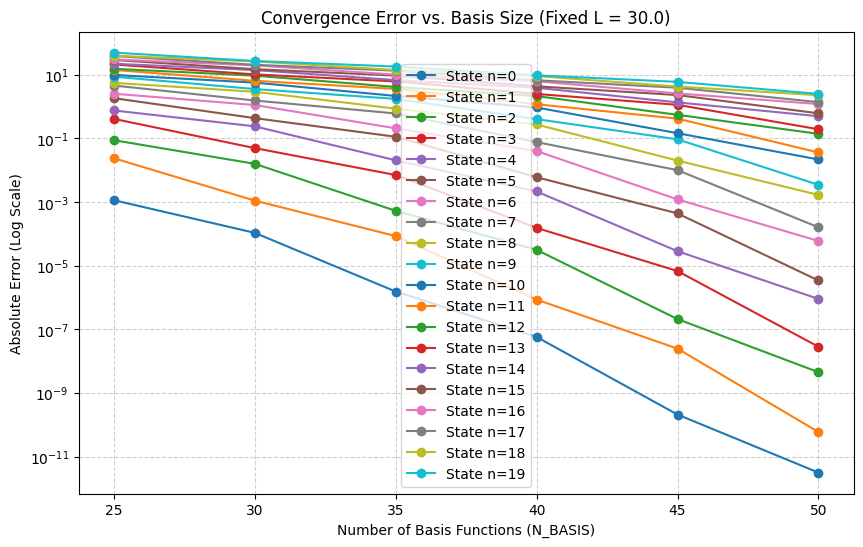

In [17]:
# ==========================================
# EXPERIMENT 1: Error vs. N_BASIS (Fixed L)
# ==========================================

# Experimental Setup
L_fixed = 30.0
basis_sizes = np.arange(25, 55, 5) # Test N_BASIS from 25 to 55 in steps of 5
tracked_states = 20                # Track the first 20 states for a clean graph

exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
errors_vs_N = []

print(f"Sweeping N_BASIS from 25 to 55 with fixed L={L_fixed}...")

for N in basis_sizes:
    # We pass the experimental N directly into your math engine
    calc_energies, _ = calculate_qho_energies_and_states(
        L_val=L_fixed, 
        N_BASIS_val=N, 
        N_STATES_val=tracked_states
    )
    
    # Calculate the absolute error against the theoretical formula
    error = np.abs(calc_energies - exact_energies)
    errors_vs_N.append(error)

# Convert list to a 2D NumPy array for easy plotting slicing
errors_vs_N = np.array(errors_vs_N)

# --- Matplotlib Plotting ---
plt.figure(figsize=(10, 6))
for state in range(tracked_states):
    # Using a logarithmic y-axis to see the exponential convergence
    plt.semilogy(basis_sizes, errors_vs_N[:, state], marker='o', label=f'State n={state}')

plt.title(f'Convergence Error vs. Basis Size (Fixed L = {L_fixed})')
plt.xlabel('Number of Basis Functions (N_BASIS)')
plt.ylabel('Absolute Error (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

In [18]:
# calc_energies

In [19]:
errors

array([3.12516679e-12, 5.90829607e-11, 4.47804283e-09, 2.82022494e-08,
       8.99302024e-07])

Sweeping L from 10.0 to 40.0 with fixed N_BASIS=60...


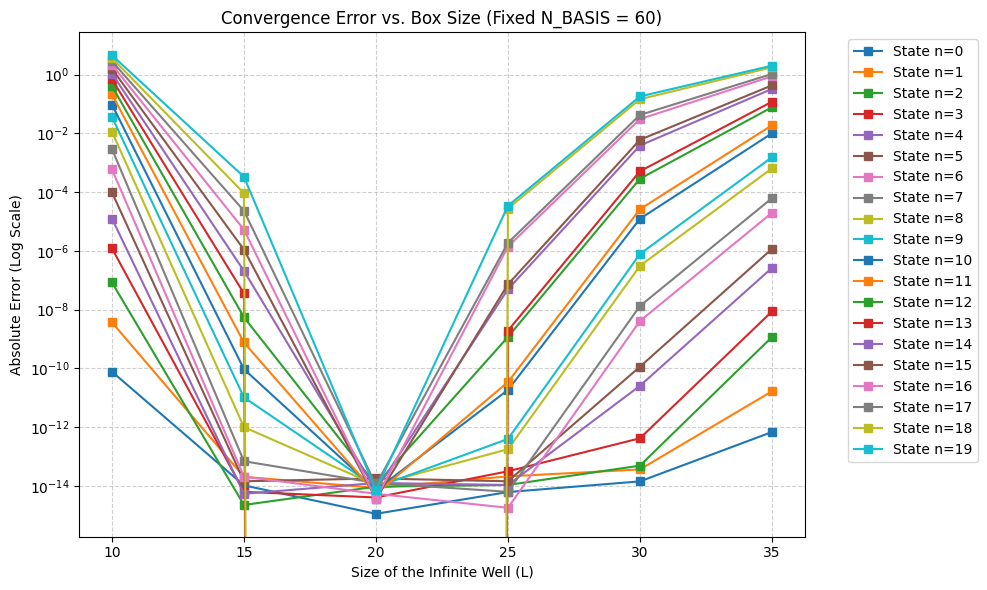

In [20]:
# ==========================================
# EXPERIMENT 2: Error vs. Box Size L (Fixed N_BASIS)
# ==========================================

# Experimental Setup
N_fixed = 60  # Using the optimal basis size from your previous graphs
L_values = np.arange(10.0, 40.0, 5) # Test L from 10 to 40 in steps of 5
tracked_states = 20

exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
errors_vs_L = []

print(f"Sweeping L from 10.0 to 40.0 with fixed N_BASIS={N_fixed}...")

for L_val in L_values:
    # Pass the experimental L directly into your math engine
    calc_energies, _ = calculate_qho_energies_and_states(
        L_val=L_val, 
        N_BASIS_val=N_fixed, 
        N_STATES_val=tracked_states
    )
    error = np.abs(calc_energies - exact_energies)
    errors_vs_L.append(error)

errors_vs_L = np.array(errors_vs_L)

# --- Matplotlib Plotting ---
plt.figure(figsize=(10, 6))

# Plotting a subset of the 20 states to keep the graph readable
states_to_plot = [i for i in range(tracked_states)]

for state in states_to_plot:
    plt.semilogy(L_values, errors_vs_L[:, state], marker='s', label=f'State n={state}')

plt.title(f'Convergence Error vs. Box Size (Fixed N_BASIS = {N_fixed})')
plt.xlabel('Size of the Infinite Well (L)')
plt.ylabel('Absolute Error (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()